In [1]:
!pip install langchain_google_genai
!pip install langchain_community
!pip install chromadb


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
from dotenv import load_dotenv
from langgraph.graph import START, END, StateGraph
from langchain_openai import ChatOpenAI

In [3]:
load_dotenv(override=True)

True

In [4]:

def get_groq_llm():
    return ChatOpenAI(
        model= "openai/gpt-oss-120b",
        base_url= "https://api.groq.com/openai/v1",
        api_key= os.getenv("GROQ_API_KEY"),
        model_kwargs= {"temperature": 0.7},
        max_tokens= 1000,
        )
    
llm= get_groq_llm()
print(llm)

C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\interactiveshell.py:3748: UserWarning: Parameters {'temperature'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  exec(code_obj, self.user_global_ns, self.user_ns)


metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14', 'langchain-openai': '1.3.5'}} output_version=None client=<openai.resources.chat.completions.completions.Completions object at 0x000001D502F0F8C0> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000001D503054440> root_client=<openai.OpenAI object at 0x000001D502655FD0> root_async_client=<openai.AsyncOpenAI object at 0x000001D5030541A0> model_name='openai/gpt-oss-120b' temperature=0.7 model_kwargs={} openai_api_key=SecretStr('**********') openai_api_base='https://api.groq.com/openai/v1' openai_proxy=None max_tokens=1000 stream_chunk_timeout=120.0


In [5]:
from langchain_core.documents import Document
from langchain_google_genai import  GoogleGenerativeAIEmbeddings

In [6]:
# Embedding model

def get_gemini_embedding_model():
    return GoogleGenerativeAIEmbeddings(model= 'models/gemini-embedding-001')

embedding_function= get_gemini_embedding_model()

In [7]:
docs = [
    Document(
        page_content="Peak Performance Gym was founded in 2015 by former Olympic athlete Marcus Chen. With over 15 years of experience in professional athletics, Marcus established the gym to provide personalized fitness solutions for people of all levels. The gym spans 10,000 square feet and features state-of-the-art equipment.",
        metadata={"source": "about.txt"}
    ),
    Document(
        page_content="Peak Performance Gym is open Monday through Friday from 5:00 AM to 11:00 PM. On weekends, our hours are 7:00 AM to 9:00 PM. We remain closed on major national holidays. Members with Premium access can enter using their key cards 24/7, including holidays.",
        metadata={"source": "hours.txt"}
    ),
    Document(
        page_content="Our membership plans include: Basic (₹1,500/month) with access to gym floor and basic equipment; Standard (₹2,500/month) adds group classes and locker facilities; Premium (₹4,000/month) includes 24/7 access, personal training sessions, and spa facilities. We offer student and senior citizen discounts of 15% on all plans. Corporate partnerships are available for companies with 10+ employees joining.",
        metadata={"source": "membership.txt"}
    ),
    Document(
        page_content="Group fitness classes at Peak Performance Gym include Yoga (beginner, intermediate, advanced), HIIT, Zumba, Spin Cycling, CrossFit, and Pilates. Beginner classes are held every Monday and Wednesday at 6:00 PM. Intermediate and advanced classes are scheduled throughout the week. The full schedule is available on our mobile app or at the reception desk.",
        metadata={"source": "classes.txt"}
    ),
    Document(
        page_content="Personal trainers at Peak Performance Gym are all certified professionals with minimum 5 years of experience. Each new member receives a complimentary fitness assessment and one free session with a trainer. Our head trainer, Neha Kapoor, specializes in rehabilitation fitness and sports-specific training. Personal training sessions can be booked individually (₹800/session) or in packages of 10 (₹7,000) or 20 (₹13,000).",
        metadata={"source": "trainers.txt"}
    ),
    Document(
        page_content="Peak Performance Gym's facilities include a cardio zone with 30+ machines, strength training area, functional fitness space, dedicated yoga studio, spin class room, swimming pool (25m), sauna and steam rooms, juice bar, and locker rooms with shower facilities. Our equipment is replaced or upgraded every 3 years to ensure members have access to the latest fitness technology.",
        metadata={"source": "facilities.txt"}
    )
]



### Vector store

In [8]:
from langchain_community.vectorstores import Chroma

vector_db = Chroma.from_documents(docs, embedding_function)

retriever= vector_db.as_retriever(search_type='mmr', search_kwargs= {'k':3})

C:\Users\ASUS\AppData\Local\Temp\ipykernel_1044\2843608265.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import Chroma


### Creating tools

In [9]:
from langchain_core.tools import tool
from langchain_core.tools.retriever import create_retriever_tool

retriever_tool= create_retriever_tool(retriever, 
                'retriever_tool', 
                'Information related to Gym History & Founder, operating hours about peak performance Gym')

@tool
def off_topic():
    """Catch all questions NOT related to peak performance GYM, history, membership plan, fitness classes, facilities
    """
    return "Forbidden- do not respond to the user"


tools= [retriever_tool, off_topic]

### Creating State

In [10]:
from typing import TypedDict, Literal, Annotated, Sequence
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

### Agent Node

In [11]:
def agent(state: AgentState):
    messages= state['messages']
    llm_with_tools= llm.bind_tools(tools)

    response= llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [12]:
def should_continue(state: AgentState)-> Literal['tool_node', END]:
    messages= state['messages']
    last_message= messages[-1]
    
    if last_message.tool_calls:
        return 'tool_node' 
    return END

### Tool Node

In [13]:
from langgraph.prebuilt import ToolNode

tool_node= ToolNode(tools)

### Creating ReAct Agent Graph

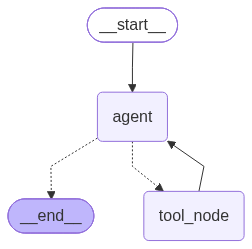

In [14]:
graph= StateGraph(AgentState)

# Nodes
graph.add_node('agent', agent)
graph.add_node('tool_node', tool_node)

# Edges
graph.add_edge(START, 'agent')
graph.add_conditional_edges('agent', should_continue)
graph.add_edge('tool_node', 'agent')

workflow= graph.compile()

workflow

### Using Agent RAG

In [ ]:
# Scenario-1

input= {'messages': HumanMessage(content= 'How will be weather today?')}

result=workflow.invoke(input)

result

{'messages': [HumanMessage(content='How will be weather today?', additional_kwargs={}, response_metadata={}, id='a284ad0e-c5a5-4f35-a25c-fa0c147c8df1'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 175, 'total_tokens': 222, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 28, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': None, 'queue_time': 0.284353924, 'prompt_time': 0.006684582, 'completion_time': 0.099405709, 'total_time': 0.106090291}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_53dd116a39', 'id': 'chatcmpl-29e206bb-3f17-4114-b9f2-42ae550b78c1', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f8969-1452-7211-b9ad-bbfcca7870e6-0', tool_calls=[{'name': 'off_topic', 'args': {}, 'id': 'fc_fd77e452-9d4b-46f5-bc49-00ef541a4c45', 't

In [17]:
# Scenario-2

input= {'messages': HumanMessage(content= 'who is the owner & what are the timing of peak performance?')}

result=workflow.invoke(input)

print(result['messages'][-1].content)

**Owner / Founder**  
Peak Performance Gym was founded (and is owned) by **Marcus Chen**, a former Olympic athlete who launched the gym in 2015.

**Operating Hours**  

| Day | Hours |
|-----|-------|
| Monday – Friday | **5:00 AM – 11:00 PM** |
| Saturday – Sunday | **7:00 AM – 9:00 PM** |
| Major national holidays | **Closed** (except Premium members who have 24/7 key‑card access) |

So, the gym is run by Marcus Chen and follows the schedule above. Let me know if you’d like details on membership plans, classes, or anything else!
